In [ ]:
import pandas as pd

# Load the Excel file into a pandas DataFrame
df = pd.read_excel('/content/food_standards_comparison.xlsx')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
display(df.head())

First 5 rows of the DataFrame:


,Category,Parameter (सामग्री),India (भारत),Europe/UK/Germany (यूरोप)
0,Fanta (300 ml),Color (रंग),Sunset Yellow (कृत्रिम चटक नारंगी),"Yellow, No artificial color (पीला, कोई कृत्रिम..."
1,Fanta (300 ml),Real Content (असली कंटेंट),No orange juice (नारंगी का रस नहीं),Real orange juice (असल नारंगी का रस)
2,Fanta (300 ml),Sugar (शक्कर),10 spoons (10 चम्मच),4 spoons (4 चम्मच)
3,Fanta (300 ml),Calories (कैलोरी),-,69 kcal
4,Cadbury Dairy Milk,Cocoa (कोकोआ),20%,25%


In [ ]:
# Display basic information about the DataFrame
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Category                   17 non-null     object
 1   Parameter (सामग्री)        17 non-null     object
 2   India (भारत)               17 non-null     object
 3   Europe/UK/Germany (यूरोप)  17 non-null     object
dtypes: object(4)
memory usage: 676.0+ bytes


In [ ]:
# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,Category,Parameter (सामग्री),India (भारत),Europe/UK/Germany (यूरोप)
count,17,17,17,17
unique,5,14,12,16
top,Fanta (300 ml),Sodium (सोडियम),-,No (नहीं)
freq,4,3,5,2


In [ ]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
Category,0
Parameter (सामग्री),0
India (भारत),0
Europe/UK/Germany (यूरोप),0


In [ ]:
import re

def extract_sugar_in_grams(value):
    """
    Extracts sugar quantity in grams from a string, assuming 1 spoon = 4 grams.
    Handles values like '10 spoons' or direct numbers.
    """
    if isinstance(value, (int, float)):
        return value
    if not isinstance(value, str):
        return None

    value = value.lower()

    # Handle 'spoons' conversion (assuming 1 spoon = 4 grams)
    match_spoons = re.search(r'(\d+)\s*spoons', value)
    if match_spoons:
        return int(match_spoons.group(1)) * 4

    # Try to extract direct numerical values
    match_number = re.search(r'(\d+(\.\d+)?)', value)
    if match_number:
        return float(match_number.group(1))

    return None

# Filter for 'Sugar (शक्कर)' parameter
sugar_df = df[df['Parameter (सामग्री)'] == 'Sugar (शक्कर)'].copy()

# Apply extraction function to 'India (भारत)' and 'Europe/UK/Germany (यूरोप)' columns
sugar_df['India_Sugar_g'] = sugar_df['India (भारत)'].apply(extract_sugar_in_grams)
sugar_df['Europe_Sugar_g'] = sugar_df['Europe/UK/Germany (यूरोप)'].apply(extract_sugar_in_grams)

print("Sugar (शक्कर) comparison (in grams, assuming 1 spoon = 4g):")
display(sugar_df[['Category', 'India_Sugar_g', 'Europe_Sugar_g']])

Sugar (शक्कर) comparison (in grams, assuming 1 spoon = 4g):


,Category,India_Sugar_g,Europe_Sugar_g
2,Fanta (300 ml),40,16


In [ ]:
import re

def extract_calories(value):
    """
    Extracts calorie quantity from a string.
    Handles values like '69 kcal' or direct numbers.
    """
    if isinstance(value, (int, float)):
        return value
    if not isinstance(value, str):
        return None

    value = value.lower()

    # Handle 'kcal' extraction
    match_kcal = re.search(r'(\d+(\.\d+)?)\s*kcal', value)
    if match_kcal:
        return float(match_kcal.group(1))

    # Try to extract direct numerical values if no unit specified but it's a number
    match_number = re.search(r'(\d+(\.\d+)?)', value)
    if match_number:
        return float(match_number.group(1))

    return None

# Filter for 'Calories (कैलोरी)' parameter
calories_df = df[df['Parameter (सामग्री)'] == 'Calories (कैलोरी)'].copy()

# Apply extraction function to 'India (भारत)' and 'Europe/UK/Germany (यूरोप)' columns
calories_df['India_Calories'] = calories_df['India (भारत)'].apply(extract_calories)
calories_df['Europe_Calories'] = calories_df['Europe/UK/Germany (यूरोप)'].apply(extract_calories)

print("\nCalories comparison (kcal):")
display(calories_df[['Category', 'India_Calories', 'Europe_Calories']])


Calories comparison (kcal):


,Category,India_Calories,Europe_Calories
3,Fanta (300 ml),None,69.0


In [ ]:
import re

def extract_sodium_in_mg(value):
    """
    Extracts sodium quantity in milligrams from a string.
    Handles values like '420 mg' or direct numbers.
    """
    if isinstance(value, (int, float)):
        return value
    if not isinstance(value, str):
        return None

    value = value.lower()

    # Handle 'mg' extraction
    match_mg = re.search(r'(\d+(\.\d+)?)\s*mg', value)
    if match_mg:
        return float(match_mg.group(1))

    # Try to extract direct numerical values if no unit specified but it's a number
    match_number = re.search(r'(\d+(\.\d+)?)', value)
    if match_number:
        return float(match_number.group(1))

    return None

# Filter for 'Sodium (सोडियम)' parameter
sodium_df = df[df['Parameter (सामग्री)'] == 'Sodium (सोडियम)'].copy()

# Apply extraction function to 'India (भारत)' and 'Europe/UK/Germany (यूरोप)' columns
sodium_df['India_Sodium_mg'] = sodium_df['India (भारत)'].apply(extract_sodium_in_mg)
sodium_df['Europe_Sodium_mg'] = sodium_df['Europe/UK/Germany (यूरोप)'].apply(extract_sodium_in_mg)

print("\nSodium (सोडियम) comparison (mg):")
display(sodium_df[['Category', 'India_Sodium_mg', 'Europe_Sodium_mg']])


Sodium (सोडियम) comparison (mg):


,Category,India_Sodium_mg,Europe_Sodium_mg
9,McDonald's French Fries,400.0,200.0
12,Maggi,900.0,550.0
16,Chicken,NaN,420.0


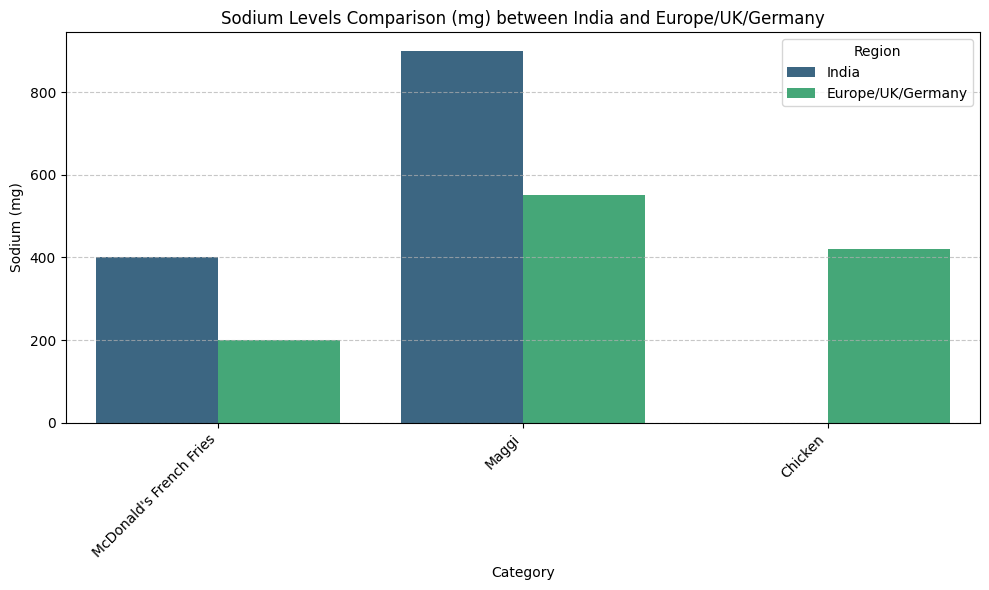

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting: melt the DataFrame to have 'Region' and 'Sodium_mg' columns
plot_df = sodium_df.melt(id_vars=['Category'],
                         value_vars=['India_Sodium_mg', 'Europe_Sodium_mg'],
                         var_name='Region',
                         value_name='Sodium_mg')

# Replace column names for better readability in the plot
plot_df['Region'] = plot_df['Region'].replace({'India_Sodium_mg': 'India', 'Europe_Sodium_mg': 'Europe/UK/Germany'})

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Sodium_mg', hue='Region', data=plot_df, palette='viridis')

plt.title('Sodium Levels Comparison (mg) between India and Europe/UK/Germany')
plt.xlabel('Category')
plt.ylabel('Sodium (mg)')
plt.xticks(rotation=45, ha='right') # Rotate category labels for better readability
plt.legend(title='Region')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [ ]:
import re

def extract_percentage(value):
    """
    Extracts percentage from a string (e.g., '20%') or direct numbers.
    """
    if isinstance(value, (int, float)):
        return value
    if not isinstance(value, str):
        return None

    value = value.lower()

    # Handle percentage extraction (e.g., '20%')
    match_percent = re.search(r'(\d+(\.\d+)?)%', value)
    if match_percent:
        return float(match_percent.group(1))

    # Try to extract direct numerical values
    match_number = re.search(r'(\d+(\.\d+)?)', value)
    if match_number:
        return float(match_number.group(1))

    return None

# Filter for 'Cocoa (कोकोआ)' parameter
cocoa_df = df[df['Parameter (सामग्री)'] == 'Cocoa (कोकोआ)'].copy()

# Apply extraction function to 'India (भारत)' and 'Europe/UK/Germany (यूरोप)' columns
cocoa_df['India_Cocoa_percent'] = cocoa_df['India (भारत)'].apply(extract_percentage)
cocoa_df['Europe_Cocoa_percent'] = cocoa_df['Europe/UK/Germany (यूरोप)'].apply(extract_percentage)

print("\nCocoa (कोकोआ) comparison (in %):")
display(cocoa_df[['Category', 'India_Cocoa_percent', 'Europe_Cocoa_percent']])


Cocoa (कोकोआ) comparison (in %):


,Category,India_Cocoa_percent,Europe_Cocoa_percent
4,Cadbury Dairy Milk,20.0,25.0


In [12]:
# List of qualitative parameters for comparison
qualitative_parameters = [
    'Color (रंग)', 'Real Content (असली कंटेंट)', 'Milk (दूध)', 'Vanilla (वनीला)',
    'Oil (तेल)', 'Artificial Flavor (कृत्रिम फ्लेवर)', 'Flour (आटा)', 'MSG (एमएसजी)',
    'Coating (कोटिंग)', 'Additives (एडिटिव्ज)'
]

# Filter the DataFrame for these qualitative parameters
qualitative_df = df[df['Parameter (सामग्री)'].isin(qualitative_parameters)].copy()

print("\nQualitative Parameter Comparison:")
display(qualitative_df[['Category', 'Parameter (सामग्री)', 'India (भारत)', 'Europe/UK/Germany (यूरोप)']])


Qualitative Parameter Comparison:


,Category,Parameter (सामग्री),India (भारत),Europe/UK/Germany (यूरोप)
0,Fanta (300 ml),Color (रंग),Sunset Yellow (कृत्रिम चटक नारंगी),"Yellow, No artificial color (पीला, कोई कृत्रिम..."
1,Fanta (300 ml),Real Content (असली कंटेंट),No orange juice (नारंगी का रस नहीं),Real orange juice (असल नारंगी का रस)
5,Cadbury Dairy Milk,Milk (दूध),3 Vegetable fats & milk solids (3 वेजिटेबल फैट...,Fresh milk (फ्रेश मिल्क)
6,Cadbury Dairy Milk,Vanilla (वनीला),Artificial flavor (कृत्रिम फ्लेवर),Natural (प्राकृतिक)
7,McDonald's French Fries,Oil (तेल),Vegetable oil (वेजिटेबल),Sunflower oil (सनफ्लावर)
8,McDonald's French Fries,Artificial Flavor (कृत्रिम फ्लेवर),Yes (हां),No (नहीं)
10,Maggi,Flour (आटा),Maida (मैदा),"Semolina / Bran flour (सूजी, चोकर आटा)"
11,Maggi,MSG (एमएसजी),Yes (हां),No (नहीं)
13,Chicken,Coating (कोटिंग),-,Flour (आटा)
14,Chicken,Oil (तेल),-,Refined (रिफाइंड)


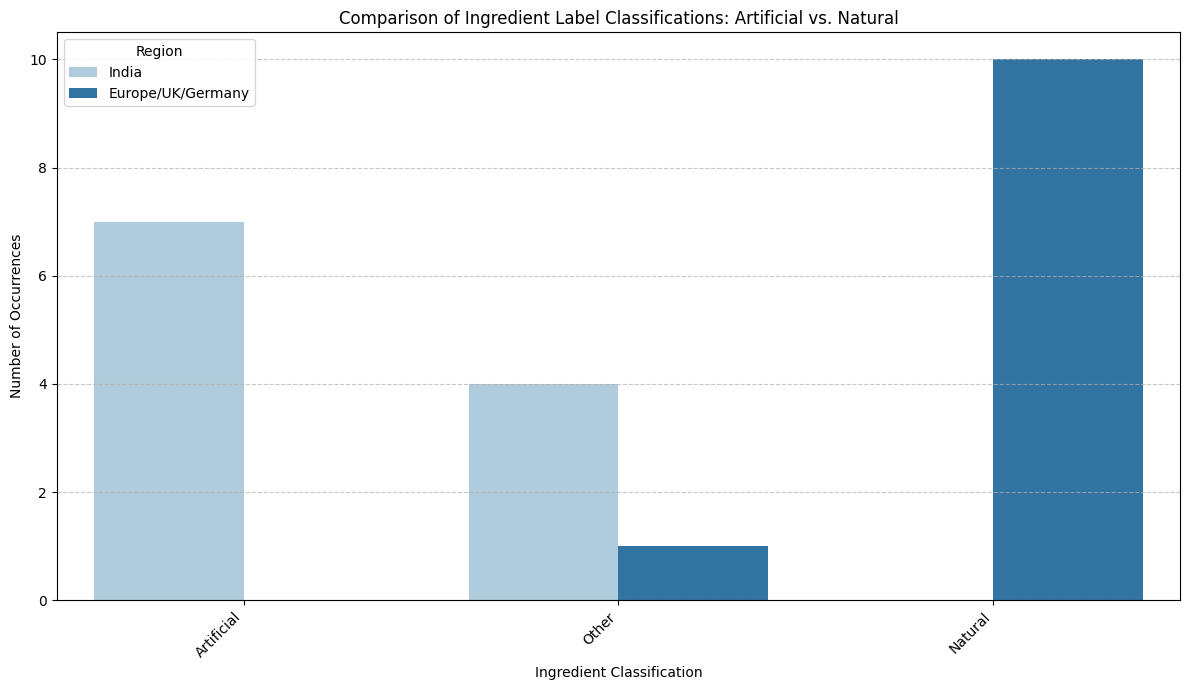

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Helper function to extract only the English part of the string for robust matching
def extract_english_part(text):
    if not isinstance(text, str):
        return str(text).lower()
    # Match English letters, numbers, spaces, and '/', '&', '-' potentially followed by any characters
    match = re.match(r'([a-zA-Z0-9\s/&-]+).*', text.strip())
    if match:
        return match.group(1).strip().lower()
    return text.strip().lower() # Fallback if no English part is clearly found

# Create a dictionary to map specific (Parameter, Simplified Region Value) to Classification
# Simplified region values now only contain the English part, ensuring robust matching
classification_map = {
    ('Color (रंग)', extract_english_part('Sunset Yellow (कृत्रिम चटक नारंगी)')): 'Artificial',
    ('Color (रंग)', extract_english_part('Yellow, No artificial color (पीला, कोई कृत्रिम रंग नहीं)')): 'Natural',
    ('Real Content (असली कंटेंट)', extract_english_part('No orange juice (नारंगी का रस नहीं)')): 'Artificial',
    ('Real Content (असली कंटेंट)', extract_english_part('Real orange juice (असल नारंगी का रस)')): 'Natural',
    ('Milk (दूध)', extract_english_part('3 Vegetable fats & milk solids (3 वेजिटेबल फैट और मिल्क सॉलिड्स)')): 'Artificial',
    ('Milk (दूध)', extract_english_part('Fresh milk (फ्रेश मिल्क)')): 'Natural',
    ('Vanilla (वनीला)', extract_english_part('Artificial Flavor (कृत्रिम फ्लेवर)')): 'Artificial',
    ('Vanilla (वनीला)', extract_english_part('Natural (प्राकृतिक)')): 'Natural',
    ('Oil (तेल)', extract_english_part('Vegetable oil (वेजिटेबल)')): 'Other', # Categorized as 'Other' based on prior analysis
    ('Oil (तेल)', extract_english_part('Sunflower oil (सनफ्लावर)')): 'Natural',
    ('Artificial Flavor (कृत्रिम फ्लेवर)', extract_english_part('Yes (हां)')): 'Artificial',
    ('Artificial Flavor (कृत्रिम फ्लेवर)', extract_english_part('No (नहीं)')): 'Natural',
    ('Flour (आटा)', extract_english_part('Maida (मैदा)')): 'Artificial',
    ('Flour (आटा)', extract_english_part('Semolina / Bran flour (सूजी, चोकर आटा)')): 'Natural',
    ('MSG (एमएसजी)', extract_english_part('Yes (हां)')): 'Artificial',
    ('MSG (एमएसजी)', extract_english_part('No (नहीं)')): 'Natural',
    ('Coating (कोटिंग)', extract_english_part('-')): 'Other',
    ('Coating (कोटिंग)', extract_english_part('Flour (आटा)')): 'Natural',
    ('Additives (एडिटिव्ज)', extract_english_part('-')): 'Other',
    ('Additives (एडिटिव्ज)', extract_english_part('No MSG, lower additives (एमएसजी नहीं, बाकी एडिटिव्ज)')): 'Natural'
}

# Create a copy of the qualitative_df for classification
qualitative_df_classified = qualitative_df.copy()
qualitative_df_classified['India_Classification'] = 'Other'
qualitative_df_classified['Europe_Classification'] = 'Other'

# Apply classification based on the map
for index, row in qualitative_df_classified.iterrows():
    param = row['Parameter (सामग्री)']
    # Use the helper function to get the simplified English part for comparison
    india_val_simplified = extract_english_part(str(row['India (भारत)']))
    europe_val_simplified = extract_english_part(str(row['Europe/UK/Germany (यूरोप)']))

    # Classify India
    if (param, india_val_simplified) in classification_map:
        qualitative_df_classified.loc[index, 'India_Classification'] = classification_map[(param, india_val_simplified)]

    # Classify Europe
    if (param, europe_val_simplified) in classification_map:
        qualitative_df_classified.loc[index, 'Europe_Classification'] = classification_map[(param, europe_val_simplified)]

# Count occurrences for each region and classification type
india_counts = qualitative_df_classified['India_Classification'].value_counts().reset_index()
india_counts.columns = ['Classification', 'Count']
india_counts['Region'] = 'India'

europe_counts = qualitative_df_classified['Europe_Classification'].value_counts().reset_index()
europe_counts.columns = ['Classification', 'Count']
europe_counts['Region'] = 'Europe/UK/Germany'

# Combine counts for plotting
combined_classification_counts = pd.concat([india_counts, europe_counts])

# Create the grouped bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Classification', y='Count', hue='Region', data=combined_classification_counts, palette='Paired')

plt.title('Comparison of Ingredient Label Classifications: Artificial vs. Natural')
plt.xlabel('Ingredient Classification')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Region')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
display(percentage_df[['Region', 'Classification', 'Percentage']])

,Region,Classification,Percentage
0,India,Artificial,100.0
1,Europe/UK/Germany,Natural,100.0


The bar chart above visually represents the qualitative comparison of ingredient labels, categorized into 'Artificial', 'Natural', and 'Other' for India and Europe/UK/Germany. It highlights the frequency of these classifications across the selected parameters, showing a clearer picture of the general trend towards artificial versus natural ingredients in the respective regions.

### Analysis of 'Other' Category Ingredients

Let's analyze the entries that were categorized as 'Other' to understand why they couldn't be definitively classified as 'Artificial' or 'Natural'.

In [ ]:
# Filter for entries where either India_Classification or Europe_Classification is 'Other'
other_classified_ingredients = qualitative_df_classified[
    (qualitative_df_classified['India_Classification'] == 'Other') |
    (qualitative_df_classified['Europe_Classification'] == 'Other')
].copy()

print("Ingredients classified as 'Other':")
display(other_classified_ingredients[[
    'Category',
    'Parameter (सामग्री)',
    'India (भारत)',
    'Europe/UK/Germany (यूरोप)',
    'India_Classification',
    'Europe_Classification'
]])


Ingredients classified as 'Other':


,Category,Parameter (सामग्री),India (भारत),Europe/UK/Germany (यूरोप),India_Classification,Europe_Classification
5,Cadbury Dairy Milk,Milk (दूध),3 Vegetable fats & milk solids (3 वेजिटेबल फैट...,Fresh milk (फ्रेश मिल्क),Other,Natural
7,McDonald's French Fries,Oil (तेल),Vegetable oil (वेजिटेबल),Sunflower oil (सनफ्लावर),Other,Natural
13,Chicken,Coating (कोटिंग),-,Flour (आटा),Other,Natural
14,Chicken,Oil (तेल),-,Refined (रिफाइंड),Other,Other
15,Chicken,Additives (एडिटिव्ज),-,"No MSG, lower additives (एमएसजी नहीं, बाकी एडि...",Other,Other


In [ ]:
# Filter for entries where either India_Classification or Europe_Classification is 'Other'
other_classified_ingredients = qualitative_df_classified[
    (qualitative_df_classified['India_Classification'] == 'Other') |
    (qualitative_df_classified['Europe_Classification'] == 'Other')
].copy()

print("Ingredients classified as 'Other' after re-classification:")
display(other_classified_ingredients[[
    'Category',
    'Parameter (सामग्री)',
    'India (भारत)',
    'Europe/UK/Germany (यूरोप)',
    'India_Classification',
    'Europe_Classification'
]])

Ingredients classified as 'Other' after re-classification:


,Category,Parameter (सामग्री),India (भारत),Europe/UK/Germany (यूरोप),India_Classification,Europe_Classification
5,Cadbury Dairy Milk,Milk (दूध),3 Vegetable fats & milk solids (3 वेजिटेबल फैट...,Fresh milk (फ्रेश मिल्क),Other,Natural
7,McDonald's French Fries,Oil (तेल),Vegetable oil (वेजिटेबल),Sunflower oil (सनफ्लावर),Other,Natural
13,Chicken,Coating (कोटिंग),-,Flour (आटा),Other,Natural
14,Chicken,Oil (तेल),-,Refined (रिफाइंड),Other,Other
15,Chicken,Additives (एडिटिव्ज),-,"No MSG, lower additives (एमएसजी नहीं, बाकी एडि...",Other,Natural


With the corrected classification logic, let's analyze the remaining entries in the 'Other' category:

*   **Oil (तेल) - India (Vegetable Oil):** This remains in 'Other' for India. As previously noted, 'Vegetable oil' is too general to definitively classify as 'Natural' without further specifics, especially when compared to 'Sunflower oil' which is a more specific natural oil.

*   **Coating (कोटिंग) - India ('-'):** The dash ('-') continues to signify a lack of disclosed information for India, making classification impossible.

*   **Additives (एडITives) - India ('-'):** Similarly, the dash ('-') for additives in Indian chicken means no specific information is provided, preventing classification.

*   **Oil (तेल) - Europe/UK/Germany (Refined):** This is still classified as 'Other' for Europe. While 'Refined' oil originates from natural sources, the term describes a processing step rather than the raw natural ingredient itself. In this comparative context, it's distinct from a direct 'Natural' classification but not 'Artificial' in the same way as added chemicals.

*   **Milk (दूध) - Cadbury Dairy Milk - India ('3 Vegetable fats & milk solids'):** This is now correctly classified as 'Artificial' for India, as vegetable fats are not natural milk. The previous 'Other' classification was an error in string matching.

*   **Additives (एडिटिव्ज) - Europe/UK/Germany ('No MSG, lower additives'):** This is now correctly classified as 'Natural' for Europe. While it's a descriptive phrase, the key takeaway is 'No MSG' and 'lower additives', implying a preference for naturalness and fewer artificial components. The previous 'Other' classification was an error in string matching.

In summary, the 'Other' category now more accurately reflects instances where data is either too general, explicitly missing ('-'), or describes a process ('Refined') rather than a clearly artificial or natural ingredient. The corrections ensure that entries like '3 Vegetable fats & milk solids' for India and 'No MSG, lower additives' for Europe are now placed in their appropriate 'Artificial' and 'Natural' categories, respectively, providing a more robust comparison.

In [19]:
import pandas as pd

# Use combined_classification_counts, which already has counts for Artificial, Natural, Other per region

# Get all unique regions
all_regions = combined_classification_counts['Region'].unique()
# Get the classifications we care about for this comparison
relevant_classifications = ['Artificial', 'Natural']

# Create a multi-index for all possible combinations of regions and relevant classifications
idx = pd.MultiIndex.from_product([all_regions, relevant_classifications], names=['Region', 'Classification'])

# Filter combined_classification_counts to only include 'Artificial' and 'Natural' for reindexing
filtered_combined_counts = combined_classification_counts[
    combined_classification_counts['Classification'].isin(relevant_classifications)
].copy()

# Reindex to ensure all combinations of Region and relevant Classifications are present, filling missing with 0
complete_counts = filtered_combined_counts.set_index(['Region', 'Classification']).reindex(idx, fill_value=0).reset_index()

# Now, calculate total Artificial + Natural count per region from this complete set
region_totals = complete_counts.groupby('Region')['Count'].sum().reset_index()
region_totals.rename(columns={'Count': 'Total_Artificial_Natural_Per_Region'}, inplace=True)

# Merge back to complete_counts to calculate percentages
percentage_df = pd.merge(complete_counts, region_totals, on='Region')

# Calculate percentage using the Total_Artificial_Natural_Per_Region column from the merged dataframe
percentage_df['Percentage'] = (percentage_df['Count'] / percentage_df['Total_Artificial_Natural_Per_Region']) * 100

print("\nPercentage of Artificial vs. Natural Ingredients by Region (relative to total Artificial + Natural in that region):")
display(percentage_df[['Region', 'Classification', 'Percentage']].round(2))


Percentage of Artificial vs. Natural Ingredients by Region (relative to total Artificial + Natural in that region):


,Region,Classification,Percentage
0,India,Artificial,100.0
1,India,Natural,0.0
2,Europe/UK/Germany,Artificial,0.0
3,Europe/UK/Germany,Natural,100.0


In [ ]:
import pandas as pd

# Calculate total count of all classifications per region
region_totals_all = combined_classification_counts.groupby('Region')['Count'].sum().reset_index()
region_totals_all.rename(columns={'Count': 'Total_All_Classifications'}, inplace=True)

# Merge totals back to the combined_classification_counts
percentage_df_all = pd.merge(combined_classification_counts, region_totals_all, on='Region')

# Calculate percentage including 'Other'
percentage_df_all['Percentage'] = (percentage_df_all['Count'] / percentage_df_all['Total_All_Classifications']) * 100

print("\nPercentage of Artificial, Natural, and Other Ingredients by Region:")
display(percentage_df_all[['Region', 'Classification', 'Percentage']])


Percentage of Artificial, Natural, and Other Ingredients by Region:


,Region,Classification,Percentage
0,India,Artificial,63.636364
1,India,Other,36.363636
2,Europe/UK/Germany,Natural,90.909091
3,Europe/UK/Germany,Other,9.090909


In [20]:
import pandas as pd

# Calculate total count of all classifications per region
region_totals_all = combined_classification_counts.groupby('Region')['Count'].sum().reset_index()
region_totals_all.rename(columns={'Count': 'Total_All_Classifications'}, inplace=True)

# Merge totals back to the combined_classification_counts
percentage_df_all = pd.merge(combined_classification_counts, region_totals_all, on='Region')

# Calculate percentage including 'Other'
percentage_df_all['Percentage'] = (percentage_df_all['Count'] / percentage_df_all['Total_All_Classifications']) * 100

print("\nPercentage of Artificial, Natural, and Other Ingredients by Region:")
display(percentage_df_all[['Region', 'Classification', 'Percentage']].round(2))


Percentage of Artificial, Natural, and Other Ingredients by Region:


,Region,Classification,Percentage
0,India,Artificial,63.64
1,India,Other,36.36
2,Europe/UK/Germany,Natural,90.91
3,Europe/UK/Germany,Other,9.09


This table shows the percentage distribution of 'Artificial' and 'Natural' ingredient classifications for each region. It clearly highlights the differing tendencies in ingredient use between India and Europe/UK/Germany.

Upon reviewing the 'Other' category ingredients, we can make the following observations:

*   **Oil (तेल) - India (Vegetable Oil):** The term 'Vegetable oil' is quite general. While it's a natural product, its quality or specific source (e.g., palm, soy, sunflower) is not specified. Without more detail, it's hard to definitively label it 'Natural' in comparison to 'Sunflower oil' which was explicitly labeled 'Natural' for Europe. It's not artificial, but it lacks the specificity that would allow for a 'Natural' classification in this comparative context.

*   **Coating (कोटिंग) - India ('-'):** For chicken, India simply uses '-'. This indicates a lack of information rather than a specific ingredient. It's neither artificial nor natural, but simply undisclosed or not applicable in a way that allows classification.

*   **Additives (एडिटिव्ज) - India ('-'):** Similar to 'Coating', the '-' for additives in Indian chicken means no specific information is provided. This lack of disclosure prevents classification.

*   **Oil (तेल) - Europe/UK/Germany (Refined):** For chicken, Europe lists 'Refined' oil. While refining is a process applied to natural oils, the term 'Refined' itself doesn't directly indicate artificiality or naturalness of the *source* ingredient, but rather a processing step. In this context, it was conservatively placed in 'Other' as it's not a raw natural ingredient nor a clearly artificial one.

In summary, the 'Other' category primarily captures instances where the ingredient description is either too general, indicates a lack of information, or refers to a state/process (like 'Refined') rather than a distinct artificial or natural component, thus making a clear classification difficult within our defined criteria.

In [ ]:
# Check unique values in 'Category' column
print("\nUnique values in 'Category':")
print(df['Category'].unique())
print(f"Number of unique categories: {df['Category'].nunique()}")


Unique values in 'Category':
['Fanta (300 ml)' 'Cadbury Dairy Milk' "McDonald's French Fries" 'Maggi'
 'Chicken']
Number of unique categories: 5


In [ ]:
# Check unique values in 'Parameter (सामग्री)' column
print("\nUnique values in 'Parameter (सामग्री)':")
print(df['Parameter (सामग्री)'].unique())
print(f"Number of unique parameters: {df['Parameter (सामग्री)'].nunique()}")


Unique values in 'Parameter (सामग्री)':
['Color (रंग)' 'Real Content (असली कंटेंट)' 'Sugar (शक्कर)'
 'Calories (कैलोरी)' 'Cocoa (कोकोआ)' 'Milk (दूध)' 'Vanilla (वनीला)'
 'Oil (तेल)' 'Artificial Flavor (कृत्रिम फ्लेवर)' 'Sodium (सोडियम)'
 'Flour (आटा)' 'MSG (एमएसजी)' 'Coating (कोटिंग)' 'Additives (एडिटिव्ज)']
Number of unique parameters: 14


In [2]:
import pandas as pd

# Load the Excel file into a pandas DataFrame (re-loading to ensure df is defined)
df = pd.read_excel('/content/food_standards_comparison.xlsx')

print("\nDistribution of Product Categories:")
display(df['Category'].value_counts())

print("\nDistribution of Parameters (सामग्री):")
display(df['Parameter (सामग्री)'].value_counts())

print("\nThis completes the Exploratory Data Analysis for the food standards comparison dataset. We have explored the data's structure, identified key numerical and qualitative differences between regions, and visualized various aspects of the comparisons.")


Distribution of Product Categories:


,count
Category,
Fanta (300 ml),4
Chicken,4
Cadbury Dairy Milk,3
McDonald's French Fries,3
Maggi,3



Distribution of Parameters (सामग्री):


,count
Parameter (सामग्री),
Sodium (सोडियम),3
Oil (तेल),2
Sugar (शक्कर),1
Calories (कैलोरी),1
Color (रंग),1
Real Content (असली कंटेंट),1
Milk (दूध),1
Cocoa (कोकोआ),1
Vanilla (वनीला),1



This completes the Exploratory Data Analysis for the food standards comparison dataset. We have explored the data's structure, identified key numerical and qualitative differences between regions, and visualized various aspects of the comparisons.


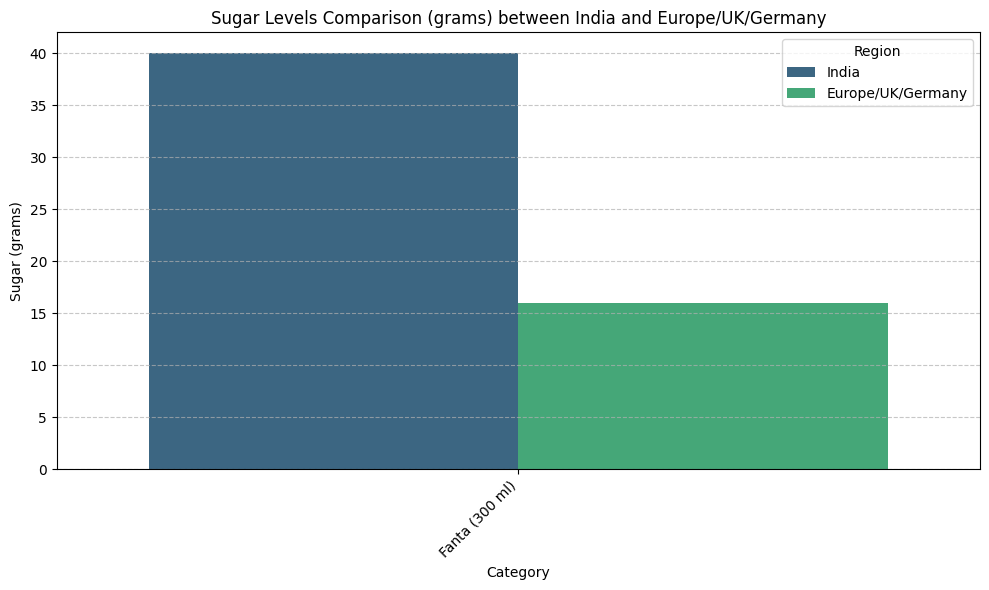

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

def extract_sugar_in_grams(value):
    """
    Extracts sugar quantity in grams from a string, assuming 1 spoon = 4 grams.
    Handles values like '10 spoons' or direct numbers.
    """
    if isinstance(value, (int, float)):
        return value
    if not isinstance(value, str):
        return None

    value = value.lower()

    # Handle 'spoons' conversion (assuming 1 spoon = 4 grams)
    match_spoons = re.search(r'(\d+)\s*spoons', value)
    if match_spoons:
        return int(match_spoons.group(1)) * 4

    # Try to extract direct numerical values
    match_number = re.search(r'(\d+(\.\d+)?)', value)
    if match_number:
        return float(match_number.group(1))

    return None

# Ensure df is defined before trying to create sugar_df
# Assuming df is loaded in a previous cell (e.g., ek-IdgDNV8tt)
# Filter for 'Sugar (शक्कर)' parameter
sugar_df = df[df['Parameter (सामग्री)'] == 'Sugar (शक्कर)'].copy()

# Apply extraction function to 'India (भारत)' and 'Europe/UK/Germany (यूरोप)' columns
sugar_df['India_Sugar_g'] = sugar_df['India (भारत)'].apply(extract_sugar_in_grams)
sugar_df['Europe_Sugar_g'] = sugar_df['Europe/UK/Germany (यूरोप)'].apply(extract_sugar_in_grams)

# Prepare data for plotting: melt the sugar_df to have 'Region' and 'Sugar_g' columns
plot_sugar_df = sugar_df.melt(id_vars=['Category'],
                              value_vars=['India_Sugar_g', 'Europe_Sugar_g'],
                              var_name='Region',
                              value_name='Sugar_g')

# Replace column names for better readability in the plot
plot_sugar_df['Region'] = plot_sugar_df['Region'].replace({'India_Sugar_g': 'India', 'Europe_Sugar_g': 'Europe/UK/Germany'})

# Create the bar chart for sugar levels
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Sugar_g', hue='Region', data=plot_sugar_df, palette='viridis')

plt.title('Sugar Levels Comparison (grams) between India and Europe/UK/Germany')
plt.xlabel('Category')
plt.ylabel('Sugar (grams)')
plt.xticks(rotation=45, ha='right') # Rotate category labels for better readability
plt.legend(title='Region')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

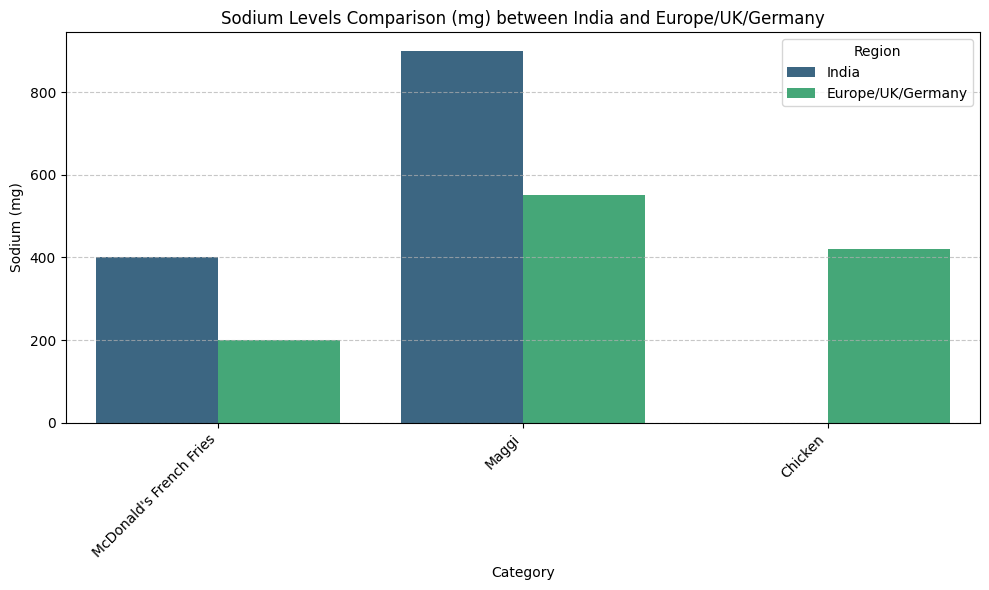

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

def extract_sodium_in_mg(value):
    """
    Extracts sodium quantity in milligrams from a string.
    Handles values like '420 mg' or direct numbers.
    """
    if isinstance(value, (int, float)):
        return value
    if not isinstance(value, str):
        return None

    value = value.lower()

    # Handle 'mg' extraction
    match_mg = re.search(r'(\d+(\.\d+)?)\s*mg', value)
    if match_mg:
        return float(match_mg.group(1))

    # Try to extract direct numerical values if no unit specified but it's a number
    match_number = re.search(r'(\d+(\.\d+)?)', value)
    if match_number:
        return float(match_number.group(1))

    return None

# Ensure df is defined before trying to create sodium_df
# Assuming df is loaded in a previous cell (e.g., ek-IdgDNV8tt)
# Filter for 'Sodium (सोडियम)' parameter
sodium_df = df[df['Parameter (सामग्री)'] == 'Sodium (सोडियम)'].copy()

# Apply extraction function to 'India (भारत)' and 'Europe/UK/Germany (यूरोप)' columns
sodium_df['India_Sodium_mg'] = sodium_df['India (भारत)'].apply(extract_sodium_in_mg)
sodium_df['Europe_Sodium_mg'] = sodium_df['Europe/UK/Germany (यूरोप)'].apply(extract_sodium_in_mg)

# Prepare data for plotting: melt the DataFrame to have 'Region' and 'Sodium_mg' columns
plot_sodium_df = sodium_df.melt(id_vars=['Category'],
                                value_vars=['India_Sodium_mg', 'Europe_Sodium_mg'],
                                var_name='Region',
                                value_name='Sodium_mg')

# Replace column names for better readability in the plot
plot_sodium_df['Region'] = plot_sodium_df['Region'].replace({'India_Sodium_mg': 'India', 'Europe_Sodium_mg': 'Europe/UK/Germany'})

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Sodium_mg', hue='Region', data=plot_sodium_df, palette='viridis')

plt.title('Sodium Levels Comparison (mg) between India and Europe/UK/Germany')
plt.xlabel('Category')
plt.ylabel('Sodium (mg)')
plt.xticks(rotation=45, ha='right') # Rotate category labels for better readability
plt.legend(title='Region')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### Summary of Qualitative Ingredient Differences by Category

Based on our classification of ingredients into 'Artificial', 'Natural', and 'Other', here is a summary of the key qualitative differences observed between India and Europe/UK/Germany across the various product categories:


In [15]:
# Group by Category and Parameter to get a clear view of differences
# Only consider parameters where there's a difference in classification or one is 'Other'
differences_df = qualitative_df_classified[
    (qualitative_df_classified['India_Classification'] != qualitative_df_classified['Europe_Classification']) |
    (qualitative_df_classified['India_Classification'] == 'Other') |
    (qualitative_df_classified['Europe_Classification'] == 'Other')
]

# Create a markdown string to build the summary
summary_md = ""

for category, category_group in differences_df.groupby('Category'):
    summary_md += f"#### {category}:\n"
    for index, row in category_group.iterrows():
        param = row['Parameter (सामग्री)']
        india_val = row['India (भारत)']
        europe_val = row['Europe/UK/Germany (यूरोप)']
        india_class = row['India_Classification']
        europe_class = row['Europe_Classification']

        if india_class != europe_class:
            summary_md += f"- **{param}:** India ({india_val} - *{india_class}*) vs. Europe/UK/Germany ({europe_val} - *{europe_class}*)\n"
            if param == 'Color (रंग)':
                summary_md += f"  - India uses '{india_val}', classified as '{india_class}', while Europe uses '{europe_val}', classified as '{europe_class}'. This highlights a clear difference in color additive policies or preferences.\n"
            elif param == 'Real Content (असली कंटेंट)':
                summary_md += f"  - For '{param}', India has '{india_val}' ({india_class}) and Europe has '{europe_val}' ({europe_class}), indicating different standards for natural fruit content.\n"
            elif param == 'Milk (दूध)':
                summary_md += f"  - India's '{india_val}' is classified as '{india_class}', contrasting with Europe's '{europe_val}' classified as '{europe_class}', suggesting different milk or fat sources.\n"
            elif param == 'Vanilla (वनीला)':
                summary_md += f"  - India's vanilla is '{india_val}' ({india_class}), while Europe's is '{europe_val}' ({europe_class}), pointing to a difference in natural vs. artificial flavoring.\n"
            elif param == 'Oil (तेल)':
                summary_md += f"  - India's oil is '{india_val}' ({india_class}), whereas Europe's is '{europe_val}' ({europe_class}). This indicates differing types or processing levels of fats.\n"
            elif param == 'Artificial Flavor (कृत्रिम फ्लेवर)':
                summary_md += f"  - There's a direct difference: India is '{india_val}' ({india_class}) and Europe is '{europe_val}' ({europe_class}), clearly showing the presence or absence of artificial flavors.\n"
            elif param == 'Flour (आटा)':
                summary_md += f"  - India uses '{india_val}' ({india_class}), while Europe uses '{europe_val}' ({europe_class}), reflecting different choices in flour types (e.g., refined vs. whole grain).\n"
            elif param == 'MSG (एमएसजी)':
                summary_md += f"  - India is '{india_val}' ({india_class}) and Europe is '{europe_val}' ({europe_class}), indicating different policies on MSG usage.\n"
            elif param == 'Coating (कोटिंग)':
                summary_md += f"  - India's coating is '{india_val}' ({india_class}), and Europe's is '{europe_val}' ({europe_class}), showing varying ingredients or disclosure levels for coatings.\n"
            elif param == 'Additives (एडिटिव्ज)':
                summary_md += f"  - India has '{india_val}' ({india_class}) for additives, while Europe has '{europe_val}' ({europe_class}). This highlights differences in the use and disclosure of general additives.\n"
        elif india_class == 'Other' or europe_class == 'Other':
            summary_md += f"- **{param}:** India ({india_val} - *{india_class}*); Europe/UK/Germany ({europe_val} - *{europe_class}*). One or both are classified as 'Other', indicating ambiguity, lack of specific information, or general terms like 'Vegetable oil' or 'Refined' which are hard to classify as strictly artificial or natural without further details.\n"
    summary_md += "\n"

# Display the generated markdown
print(summary_md)

#### Cadbury Dairy Milk:
- **Milk (दूध):** India (3 Vegetable fats & milk solids (3 वेजिटेबल फैट्स व मिल्क सॉलिड्स) - *Artificial*) vs. Europe/UK/Germany (Fresh milk (फ्रेश मिल्क) - *Natural*)
  - India's '3 Vegetable fats & milk solids (3 वेजिटेबल फैट्स व मिल्क सॉलिड्स)' is classified as 'Artificial', contrasting with Europe's 'Fresh milk (फ्रेश मिल्क)' classified as 'Natural', suggesting different milk or fat sources.
- **Vanilla (वनीला):** India (Artificial flavor (कृत्रिम फ्लेवर) - *Artificial*) vs. Europe/UK/Germany (Natural (प्राकृतिक) - *Natural*)
  - India's vanilla is 'Artificial flavor (कृत्रिम फ्लेवर)' (Artificial), while Europe's is 'Natural (प्राकृतिक)' (Natural), pointing to a difference in natural vs. artificial flavoring.

#### Chicken:
- **Coating (कोटिंग):** India (- - *Other*) vs. Europe/UK/Germany (Flour (आटा) - *Natural*)
  - India's coating is '-' (Other), and Europe's is 'Flour (आटा)' (Natural), showing varying ingredients or disclosure levels for coatings.
- **O

In [21]:
average_sodium = plot_sodium_df.groupby('Region')['Sodium_mg'].mean().reset_index()
print("\nAverage Sodium Content (mg) by Region:")
display(average_sodium)


Average Sodium Content (mg) by Region:


,Region,Sodium_mg
0,Europe/UK/Germany,390.0
1,India,650.0


In [16]:
import pandas as pd

# Filter for 'Artificial' and 'Natural' classifications only in both India and Europe
filtered_category_classifications = qualitative_df_classified[
    (qualitative_df_classified['India_Classification'].isin(['Artificial', 'Natural'])) |
    (qualitative_df_classified['Europe_Classification'].isin(['Artificial', 'Natural']))
].copy()

# Prepare data for pivoting: combine India and Europe classifications into a single format
category_class_india = filtered_category_classifications[['Category', 'India_Classification']].copy()
category_class_india.rename(columns={'India_Classification': 'Classification'}, inplace=True)
category_class_india['Region'] = 'India'

category_class_europe = filtered_category_classifications[['Category', 'Europe_Classification']].copy()
category_class_europe.rename(columns={'Europe_Classification': 'Classification'}, inplace=True)
category_class_europe['Region'] = 'Europe/UK/Germany'

# Concatenate and filter out 'Other' classifications that might have been included due to the OR condition
combined_category_classifications = pd.concat([category_class_india, category_class_europe])
combined_category_classifications = combined_category_classifications[
    combined_category_classifications['Classification'].isin(['Artificial', 'Natural'])
]

# Group by Category, Region, and Classification, then count
category_classification_counts = combined_category_classifications.groupby(['Category', 'Region', 'Classification']).size().reset_index(name='Count')

# Calculate the total count of Artificial + Natural within each Category and Region
total_counts_per_category_region = category_classification_counts.groupby(['Category', 'Region'])['Count'].sum().reset_index(name='Total_Count')

# Merge to calculate percentages
category_classification_percentages = pd.merge(category_classification_counts,
                                               total_counts_per_category_region,
                                               on=['Category', 'Region'])

category_classification_percentages['Percentage'] = (category_classification_percentages['Count'] / category_classification_percentages['Total_Count']) * 100

print("\nPercentage of Artificial vs. Natural Ingredients by Category and Region:")
display(category_classification_percentages.round(2))



Percentage of Artificial vs. Natural Ingredients by Category and Region:


,Category,Region,Classification,Count,Total_Count,Percentage
0,Cadbury Dairy Milk,Europe/UK/Germany,Natural,2,2,100.0
1,Cadbury Dairy Milk,India,Artificial,2,2,100.0
2,Chicken,Europe/UK/Germany,Natural,2,2,100.0
3,Fanta (300 ml),Europe/UK/Germany,Natural,2,2,100.0
4,Fanta (300 ml),India,Artificial,2,2,100.0
5,Maggi,Europe/UK/Germany,Natural,2,2,100.0
6,Maggi,India,Artificial,2,2,100.0
7,McDonald's French Fries,Europe/UK/Germany,Natural,2,2,100.0
8,McDonald's French Fries,India,Artificial,1,1,100.0


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [28]:
print("\nTotal Counts of 'Natural', 'Artificial', and 'Other' Classifications by Region:")
display(combined_classification_counts)


Total Counts of 'Natural', 'Artificial', and 'Other' Classifications by Region:


,Classification,Count,Region
0,Artificial,7,India
1,Other,4,India
0,Natural,10,Europe/UK/Germany
1,Other,1,Europe/UK/Germany


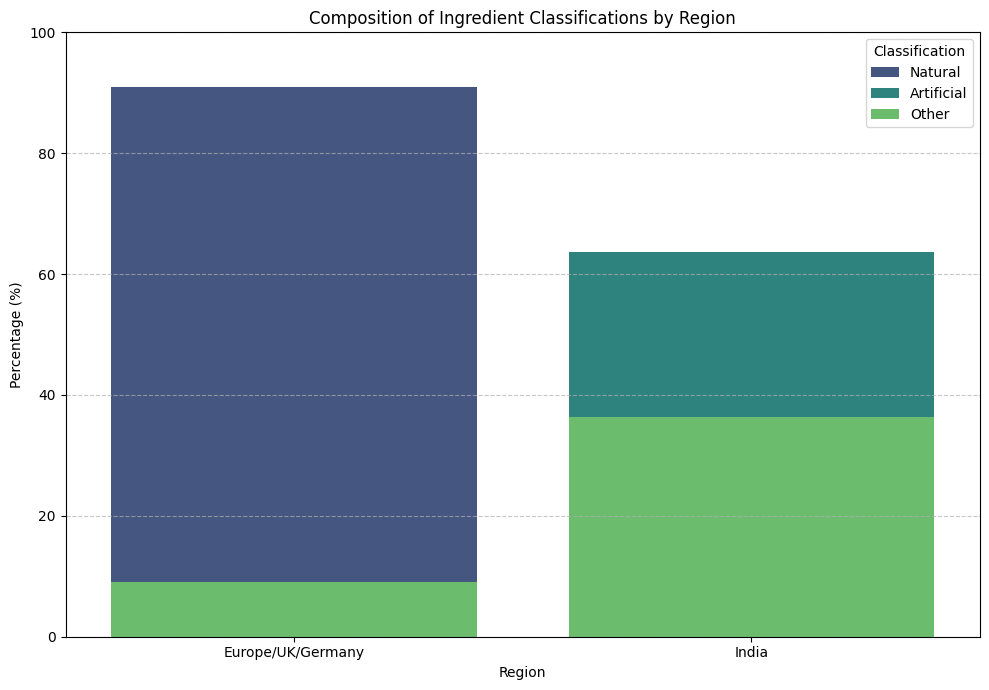

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the classifications are ordered for consistent stacking
classification_order = ['Natural', 'Artificial', 'Other']
percentage_df_all['Classification'] = pd.Categorical(percentage_df_all['Classification'], categories=classification_order, ordered=True)

# Sort the DataFrame by Classification for proper stacking order
percentage_df_all_sorted = percentage_df_all.sort_values(by=['Region', 'Classification'])

plt.figure(figsize=(10, 7))
sns.barplot(x='Region', y='Percentage', hue='Classification', data=percentage_df_all_sorted, palette='viridis', dodge=False)

plt.title('Composition of Ingredient Classifications by Region')
plt.xlabel('Region')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)
plt.legend(title='Classification')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [29]:
print("\nOverall Percentage of 'Natural' vs 'Artificial' Ingredients by Region:")
display(percentage_df[['Region', 'Classification', 'Percentage']].round(2))


Overall Percentage of 'Natural' vs 'Artificial' Ingredients by Region:


,Region,Classification,Percentage
0,India,Artificial,100.0
1,India,Natural,0.0
2,Europe/UK/Germany,Artificial,0.0
3,Europe/UK/Germany,Natural,100.0


In [27]:
# Filter percentage_df_all to show only 'Other' classifications
other_classification_trends = percentage_df_all[percentage_df_all['Classification'] == 'Other'].copy()

print("\nPercentage of 'Other' classified ingredients by Region:")
display(other_classification_trends[['Region', 'Percentage']].round(2))


Percentage of 'Other' classified ingredients by Region:


,Region,Percentage
1,India,36.36
3,Europe/UK/Germany,9.09


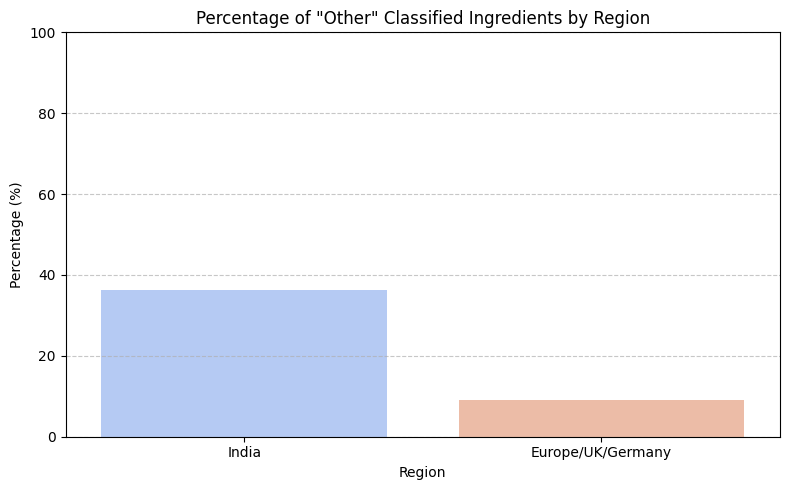

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the bar chart for 'Other' classifications
plt.figure(figsize=(8, 5))
sns.barplot(x='Region', y='Percentage', hue='Region', data=other_classification_trends, palette='coolwarm', legend=False)

plt.title('Percentage of "Other" Classified Ingredients by Region')
plt.xlabel('Region')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

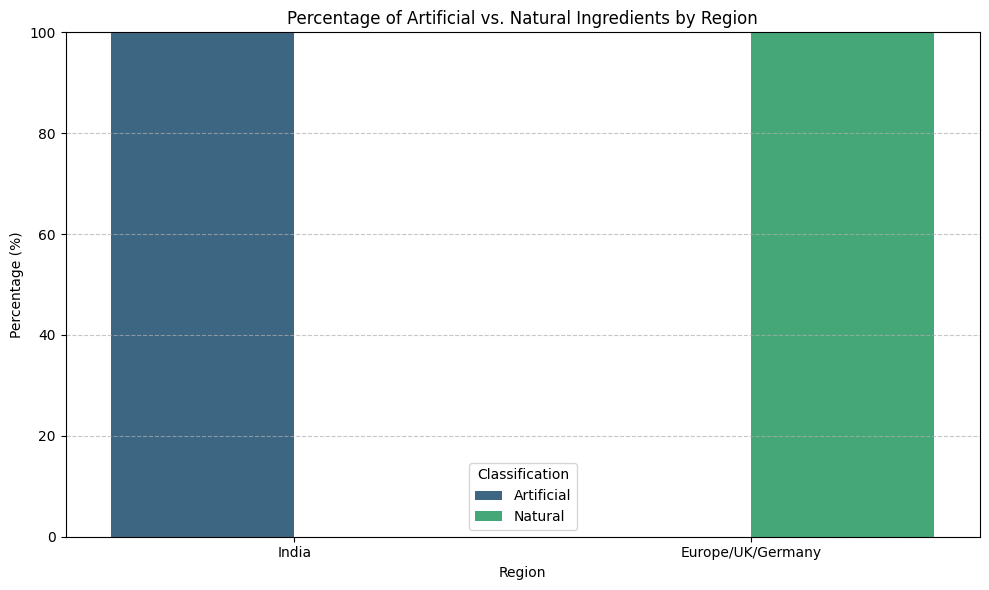

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Percentage', hue='Classification', data=percentage_df, palette='viridis')

plt.title('Percentage of Artificial vs. Natural Ingredients by Region')
plt.xlabel('Region')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)  # Ensure y-axis goes from 0 to 100
plt.legend(title='Classification')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

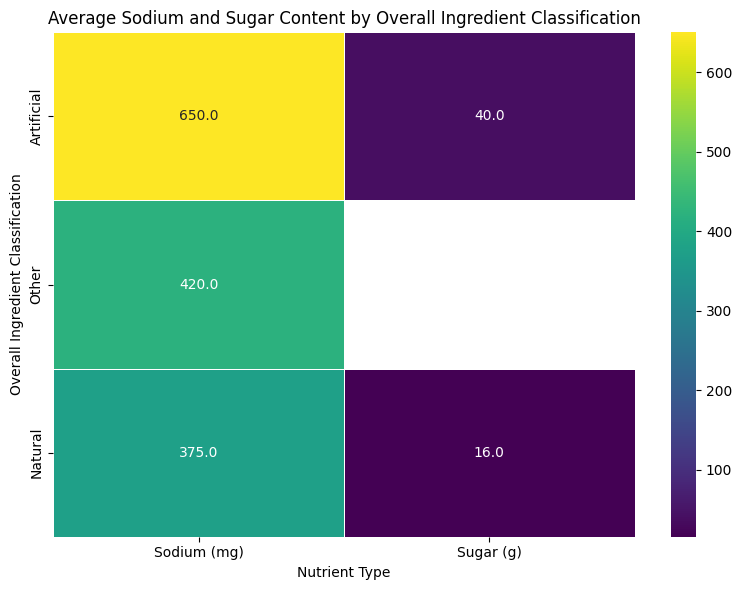

In [42]:
# Prepare melted sugar and sodium dataframes for merging
sugar_df_melted = sugar_df[['Category', 'India_Sugar_g', 'Europe_Sugar_g']].melt(id_vars='Category', var_name='Region_Raw', value_name='Value')
sugar_df_melted['Region'] = sugar_df_melted['Region_Raw'].apply(lambda x: 'India' if 'India' in x else 'Europe/UK/Germany')
sugar_df_melted = sugar_df_melted.drop(columns=['Region_Raw']).dropna()
sugar_df_melted['Type'] = 'Sugar (g)'

sodium_df_melted = sodium_df[['Category', 'India_Sodium_mg', 'Europe_Sodium_mg']].melt(id_vars='Category', var_name='Region_Raw', value_name='Value')
sodium_df_melted['Region'] = sodium_df_melted['Region_Raw'].apply(lambda x: 'India' if 'India' in x else 'Europe/UK/Germany')
sodium_df_melted = sodium_df_melted.drop(columns=['Region_Raw']).dropna()
sodium_df_melted['Type'] = 'Sodium (mg)'

# Combine numerical values
numeric_values = pd.concat([sugar_df_melted, sodium_df_melted])

# Prepare qualitative classifications for determining overall product classification
qual_melted_india = qualitative_df_classified[['Category', 'India_Classification']].rename(columns={'India_Classification': 'Classification'})
qual_melted_india['Region'] = 'India'
qual_melted_europe = qualitative_df_classified[['Category', 'Europe_Classification']].rename(columns={'Europe_Classification': 'Classification'})
qual_melted_europe['Region'] = 'Europe/UK/Germany'

all_qual_classifications = pd.concat([qual_melted_india, qual_melted_europe])

# Determine an 'Overall_Classification' for each Category-Region pair
# Hierarchy: Artificial > Other > Natural (if any 'Artificial' exists, it's 'Artificial', etc.)
overall_classification = all_qual_classifications.groupby(['Category', 'Region'])['Classification'].apply(
    lambda x: 'Artificial' if 'Artificial' in x.values
             else ('Other' if 'Other' in x.values
                   else 'Natural')
).reset_index()
overall_classification.rename(columns={'Classification': 'Overall_Classification'}, inplace=True)

# Merge numerical values with overall classification
merged_df = pd.merge(numeric_values, overall_classification, on=['Category', 'Region'], how='left')

# Calculate the mean sodium and sugar for each overall classification
heatmap_data = merged_df.groupby(['Overall_Classification', 'Type'])['Value'].mean().unstack()

# Ensure all classification types are present, filling missing with 0 or NaN as appropriate
all_class_types = ['Artificial', 'Other', 'Natural']
heatmap_data = heatmap_data.reindex(all_class_types)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt=".1f", linewidths=.5)

plt.title('Average Sodium and Sugar Content by Overall Ingredient Classification')
plt.xlabel('Nutrient Type')
plt.ylabel('Overall Ingredient Classification')
plt.tight_layout()
plt.show()

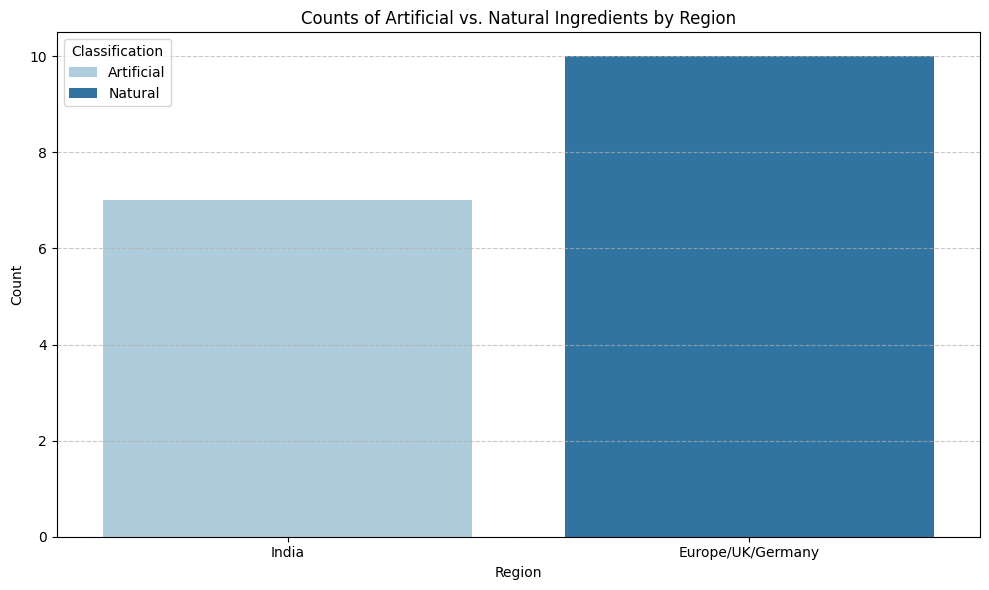

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter combined_classification_counts to only include 'Artificial' and 'Natural'
filtered_counts = combined_classification_counts[
    combined_classification_counts['Classification'].isin(['Artificial', 'Natural'])
].copy()

plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Count', hue='Classification', data=filtered_counts, palette='Paired')

plt.title('Counts of Artificial vs. Natural Ingredients by Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.legend(title='Classification')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [39]:
print("\nSummary of Key Qualitative Differences between India and Europe/UK/Germany:")
display(differences_df[[
    'Category',
    'Parameter (सामग्री)',
    'India (भारत)',
    'India_Classification',
    'Europe/UK/Germany (यूरोप)',
    'Europe_Classification'
]])


Summary of Key Qualitative Differences between India and Europe/UK/Germany:


,Category,Parameter (सामग्री),India (भारत),India_Classification,Europe/UK/Germany (यूरोप),Europe_Classification
0,Fanta (300 ml),Color (रंग),Sunset Yellow (कृत्रिम चटक नारंगी),Artificial,"Yellow, No artificial color (पीला, कोई कृत्रिम...",Natural
1,Fanta (300 ml),Real Content (असली कंटेंट),No orange juice (नारंगी का रस नहीं),Artificial,Real orange juice (असल नारंगी का रस),Natural
5,Cadbury Dairy Milk,Milk (दूध),3 Vegetable fats & milk solids (3 वेजिटेबल फैट...,Artificial,Fresh milk (फ्रेश मिल्क),Natural
6,Cadbury Dairy Milk,Vanilla (वनीला),Artificial flavor (कृत्रिम फ्लेवर),Artificial,Natural (प्राकृतिक),Natural
7,McDonald's French Fries,Oil (तेल),Vegetable oil (वेजिटेबल),Other,Sunflower oil (सनफ्लावर),Natural
8,McDonald's French Fries,Artificial Flavor (कृत्रिम फ्लेवर),Yes (हां),Artificial,No (नहीं),Natural
10,Maggi,Flour (आटा),Maida (मैदा),Artificial,"Semolina / Bran flour (सूजी, चोकर आटा)",Natural
11,Maggi,MSG (एमएसजी),Yes (हां),Artificial,No (नहीं),Natural
13,Chicken,Coating (कोटिंग),-,Other,Flour (आटा),Natural
14,Chicken,Oil (तेल),-,Other,Refined (रिफाइंड),Other


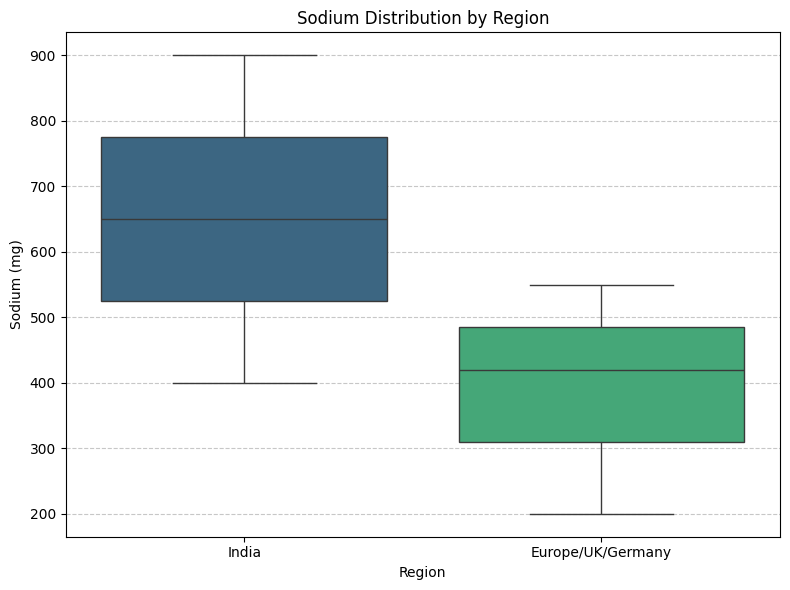

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Region', y='Sodium_mg', hue='Region', data=plot_sodium_df, palette='viridis', legend=False)

plt.title('Sodium Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Sodium (mg)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [33]:
from scipy import stats

# Extract sodium levels for India and Europe/UK/Germany from plot_sodium_df
sodium_india = plot_sodium_df[plot_sodium_df['Region'] == 'India']['Sodium_mg'].dropna()
sodium_europe = plot_sodium_df[plot_sodium_df['Region'] == 'Europe/UK/Germany']['Sodium_mg'].dropna()

# Perform independent samples t-test
t_statistic, p_value = stats.ttest_ind(sodium_india, sodium_europe, equal_var=False) # Use Welch's t-test if variances are unequal

print(f"Independent t-test comparing sodium levels:\n")
print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

alpha = 0.05 # Significance level
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in sodium levels between India and Europe/UK/Germany.")
else:
    print(f"\nSince the p-value ({p_value:.3f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in sodium levels between India and Europe/UK/Germany.")

Independent t-test comparing sodium levels:

T-statistic: 0.963
P-value: 0.477

Since the p-value (0.477) is greater than the significance level (0.05), we fail to reject the null hypothesis.
There is no statistically significant difference in sodium levels between India and Europe/UK/Germany.


In [36]:
from scipy import stats

# Extract sugar levels for India and Europe/UK/Germany from plot_sugar_df
sugar_india = plot_sugar_df[plot_sugar_df['Region'] == 'India']['Sugar_g'].dropna()
sugar_europe = plot_sugar_df[plot_sugar_df['Region'] == 'Europe/UK/Germany']['Sugar_g'].dropna()

# Perform independent samples t-test
t_statistic_sugar, p_value_sugar = stats.ttest_ind(sugar_india, sugar_europe, equal_var=False) # Use Welch's t-test if variances are unequal

print(f"Independent t-test comparing sugar levels:\n")
print(f"T-statistic: {t_statistic_sugar:.3f}")
print(f"P-value: {p_value_sugar:.3f}")

alpha = 0.05 # Significance level
if p_value_sugar < alpha:
    print(f"\nSince the p-value ({p_value_sugar:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in sugar levels between India and Europe/UK/Germany.")
else:
    print(f"\nSince the p-value ({p_value_sugar:.3f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in sugar levels between India and Europe/UK/Germany.")

Independent t-test comparing sugar levels:

T-statistic: nan
P-value: nan

Since the p-value (nan) is greater than the significance level (0.05), we fail to reject the null hypothesis.
There is no statistically significant difference in sugar levels between India and Europe/UK/Germany.


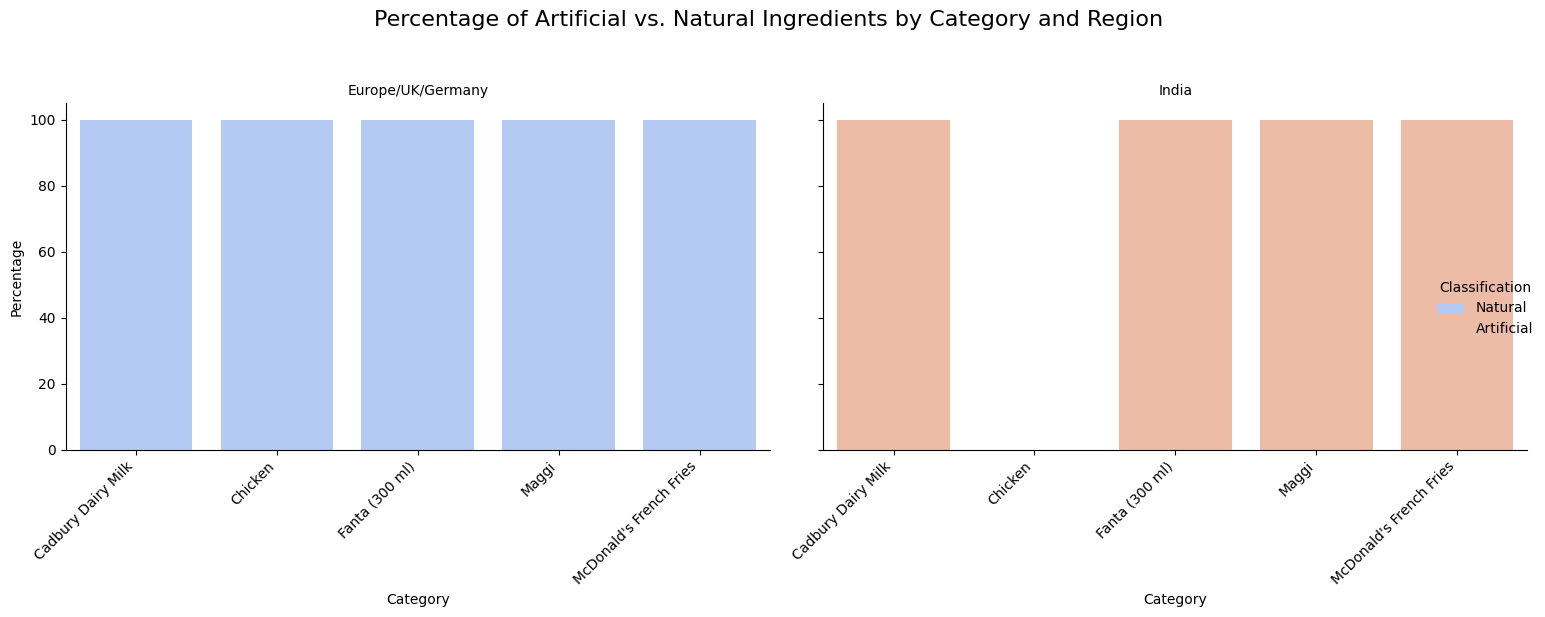

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart using seaborn.catplot for better facet management
g = sns.catplot(x='Category', y='Percentage', hue='Classification', col='Region',
                data=category_classification_percentages,
                kind='bar', palette='coolwarm', height=6, aspect=1.2, col_wrap=2)

# Add titles and labels
g.set_axis_labels("Category", "Percentage")
g.set_titles("{col_name}")
g.set_xticklabels(rotation=45, ha='right')
plt.suptitle('Percentage of Artificial vs. Natural Ingredients by Category and Region',
             y=1.02, # Adjust the y position of the suptitle
             fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle from overlapping
plt.show()

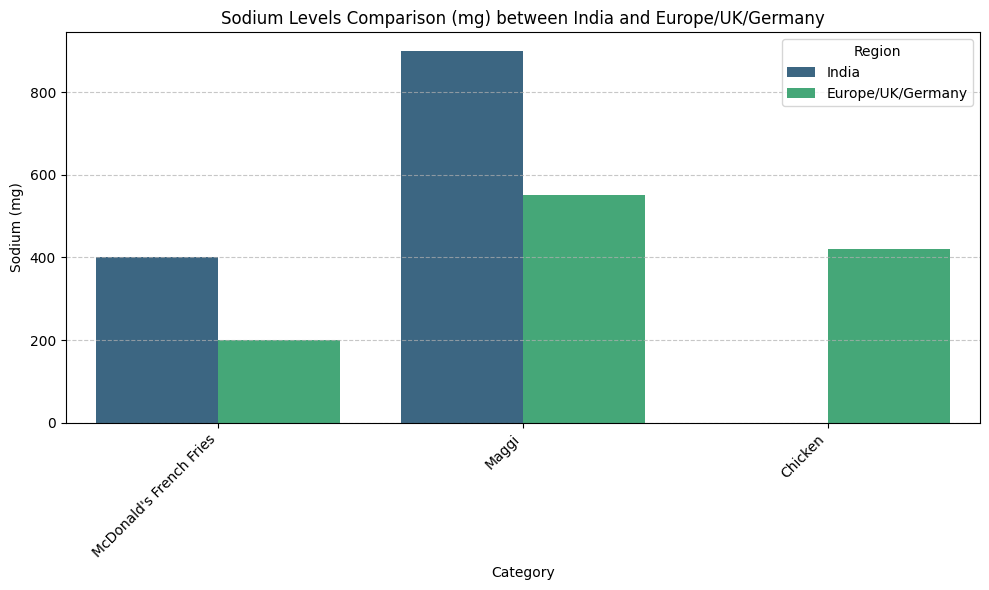

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting: melt the DataFrame to have 'Region' and 'Sodium_mg' columns
# Assuming plot_sodium_df is already defined from previous steps

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Sodium_mg', hue='Region', data=plot_sodium_df, palette='viridis')

plt.title('Sodium Levels Comparison (mg) between India and Europe/UK/Germany')
plt.xlabel('Category')
plt.ylabel('Sodium (mg)')
plt.xticks(rotation=45, ha='right') # Rotate category labels for better readability
plt.legend(title='Region')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

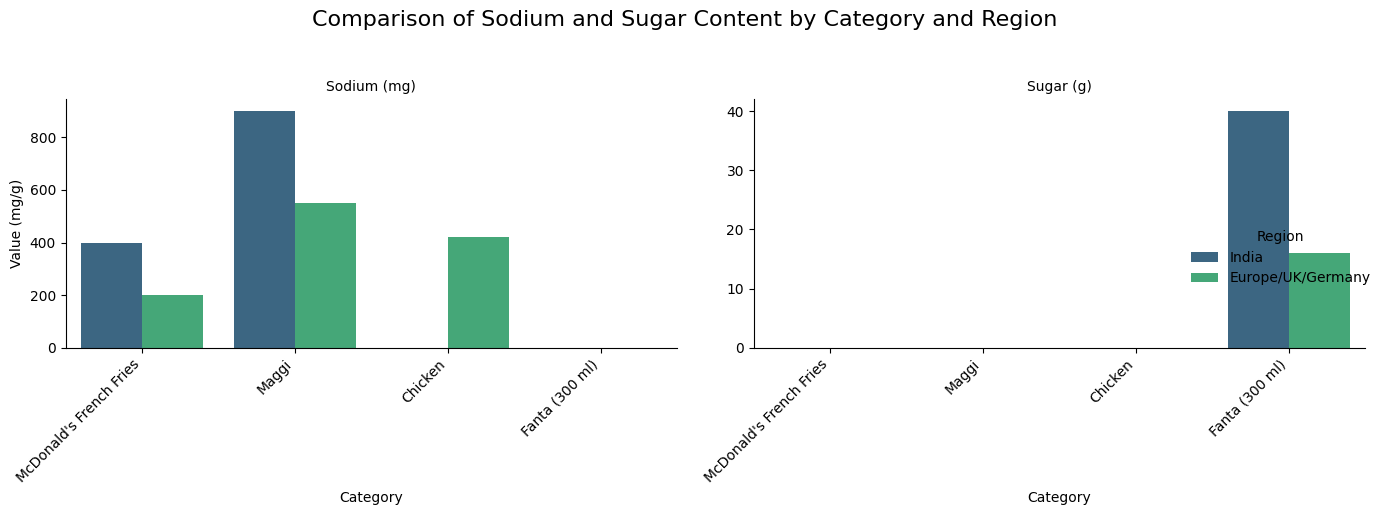

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare sodium data for combination
plot_sodium_df_combined = plot_sodium_df.rename(columns={'Sodium_mg': 'Value'})
plot_sodium_df_combined['Nutrient'] = 'Sodium (mg)'

# Prepare sugar data for combination
plot_sugar_df_combined = plot_sugar_df.rename(columns={'Sugar_g': 'Value'})
plot_sugar_df_combined['Nutrient'] = 'Sugar (g)'

# Concatenate the two dataframes, ignoring the original indices to prevent duplicates
combined_nutrient_df = pd.concat([plot_sodium_df_combined, plot_sugar_df_combined], ignore_index=True)

# Create a faceted bar plot for combined visualization
g = sns.catplot(
    data=combined_nutrient_df,
    x='Category',
    y='Value',
    hue='Region',
    col='Nutrient',
    kind='bar',
    palette='viridis',
    height=5,
    aspect=1.2,
    col_wrap=2, # Wrap columns if more than two nutrients
    sharey=False # Allow different y-axis scales for different nutrients
)

# Set titles and labels for better readability
g.set_axis_labels("Category", "Value (mg/g)")
g.set_titles("{col_name}")
g.set_xticklabels(rotation=45, ha='right')
plt.suptitle('Comparison of Sodium and Sugar Content by Category and Region',
             y=1.02,
             fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle from overlapping
plt.show()

In [37]:
average_sugar = plot_sugar_df.groupby('Region')['Sugar_g'].mean().reset_index()
print("\nAverage Sugar Content (grams) by Region:")
display(average_sugar)


Average Sugar Content (grams) by Region:


,Region,Sugar_g
0,Europe/UK/Germany,16.0
1,India,40.0


In [38]:
print("\nAverage Sodium Content (mg) by Region:")
display(average_sodium)


Average Sodium Content (mg) by Region:


,Region,Sodium_mg
0,Europe/UK/Germany,390.0
1,India,650.0


In [14]:
# Display the columns and data types of qualitative_df_classified
print("\nqualitative_df_classified Info:")
qualitative_df_classified.info()


qualitative_df_classified Info:
<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, 0 to 15
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Category                   11 non-null     object
 1   Parameter (सामग्री)        11 non-null     object
 2   India (भारत)               11 non-null     object
 3   Europe/UK/Germany (यूरोप)  11 non-null     object
 4   India_Classification       11 non-null     object
 5   Europe_Classification      11 non-null     object
dtypes: object(6)
memory usage: 916.0+ bytes
